# Model Selection and Validation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from statsmodels.graphics.tsaplots import plot_acf
import sys
from pathlib import Path
from arch import arch_model

project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.utils import load_and_preprocess_data
# load data
file_path = '../Case_Study_Data_JNM.csv'
data, returns = load_and_preprocess_data(file_path)
headers = ["HighGrowth", "Bond", "Gold", "1.5xHighGrowth", "LowGrowth"]
data.columns = headers
returns.columns = headers
returns.head()

,HighGrowth,Bond,Gold,1.5xHighGrowth,LowGrowth
date,,,,,
2001-01-31,0.019076,0.007901,-0.026237,0.028615,0.013489
2001-02-28,-0.088422,0.011679,0.007326,-0.132633,-0.038372
2001-03-31,-0.068116,0.003612,-0.035045,-0.102174,-0.032252
2001-04-30,0.071123,-0.011987,0.021212,0.106685,0.029568
2001-05-31,-0.013119,0.003680,0.011772,-0.019678,-0.004719


In [4]:
# plotting settings
primary_color = '#00246B'
secondary_color = '#CADCFC'

# global style
sns.set_style("whitegrid")
plt.rcParams['figure.autolayout'] = True
custom_palette = sns.blend_palette([primary_color, secondary_color], n_colors=5)
sns.set_palette(custom_palette)
line_styles = ['-', '--', '-.', ':', '-']

## GARCH

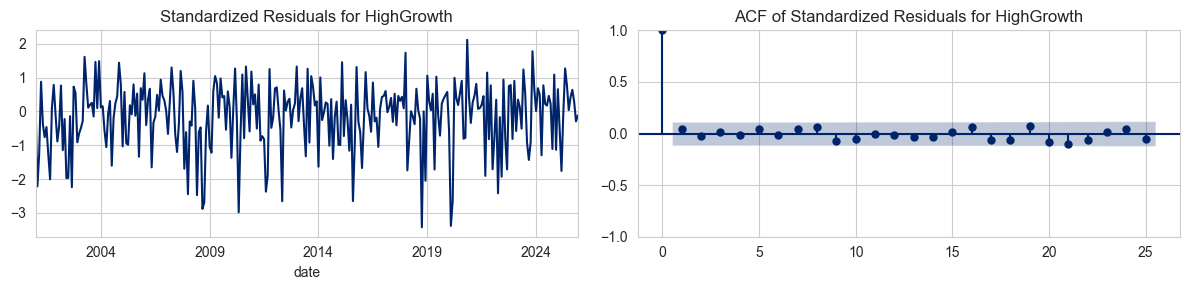

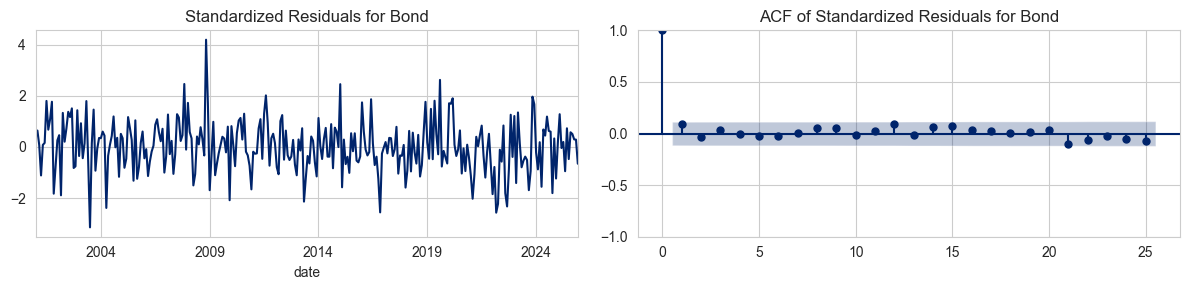

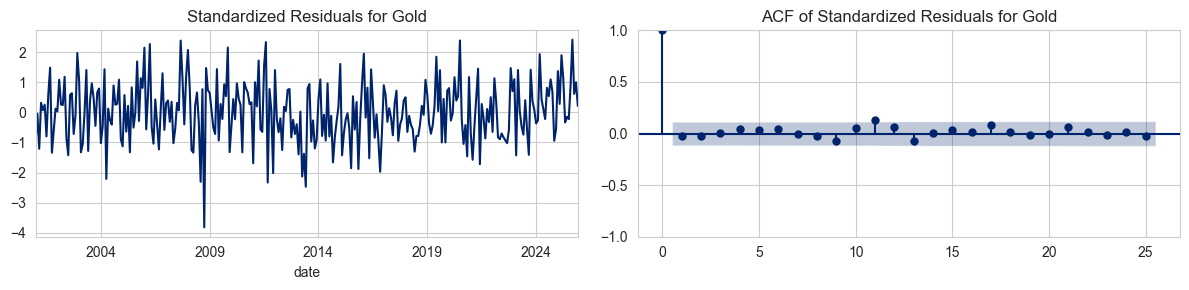

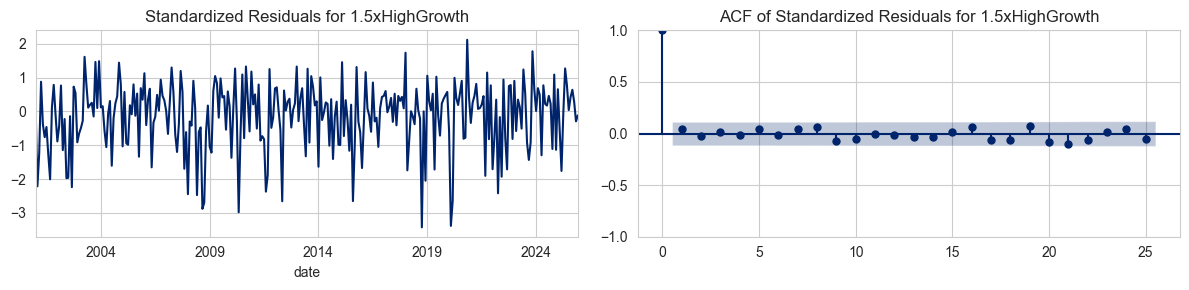

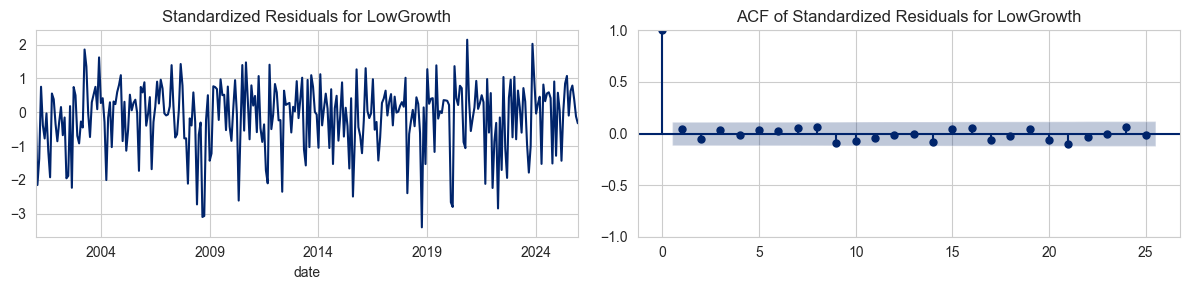

In [ ]:
# GARCH(1,1) per asset and get standardized residuals
garch_models = {}
std_residuals = pd.DataFrame(index=returns.index)

scale_factor = 100  # bring returns into ~percent units to avoid DataScaleWarning
summary_rows = []

for col in returns.columns:
    series = (returns[col] * scale_factor).dropna()
    result = arch_model(series, vol='Garch', p=1, q=1, dist='t', rescale=False).fit(disp='off')
    garch_models[col] = result
    std_residuals[col] = result.std_resid
    
    p = result.params
    summary_rows.append({
        "asset": col,
        "mu": p.get("mu", np.nan),
        "omega": p.get("omega", np.nan),
        "alpha": p.get("alpha[1]", np.nan),
        "beta": p.get("beta[1]", np.nan),
        "alpha+beta": p.get("alpha[1]", np.nan) + p.get("beta[1]", np.nan),
        "AIC": result.aic,
        "BIC": result.bic,
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    std_residuals[col].plot(ax=axes[0], title=f'Standardized Residuals for {col}')
    plot_acf(std_residuals[col].dropna(), ax=axes[1], title=f'ACF of Standardized Residuals for {col}')
    plt.tight_layout()
    plt.show()

# summary table
garch_summary = pd.DataFrame(summary_rows).set_index("asset")

In [ ]:
# GARCH summary of parameters
garch_summary

,mu,omega,alpha,beta,alpha+beta,AIC,BIC
asset,,,,,,,
HighGrowth,1.129587,1.528395,0.264992,0.681941,0.946933,1695.844805,1714.363718
Bond,0.263258,0.122310,0.088891,0.847797,0.936688,1036.742579,1055.261491
Gold,0.900791,2.109055,0.090150,0.812257,0.902407,1764.382618,1782.901530
1.5xHighGrowth,1.694155,3.436227,0.264937,0.682031,0.946968,1939.123871,1957.642783
LowGrowth,0.645409,0.360176,0.218944,0.727904,0.946848,1284.479002,1302.997915


## Dependency Structure (Copula)

Link marginal dynamics via Student-t copula to preserve linear correlation and adds **tail dependence** (joint crashes). After GARCH, each asset has roughly iid standardized residuals $z_{i,t}$ $\to$ copula couples their joint behavior without changing the marginal shapes:
- Convert standardized residuals to uniforms: $u_{i,t} = F_i(z_{i,t})$ (empirical CDF).
- Define a multivariate t distribution with correlation matrix $\Sigma$ and $\nu$ degrees of freedom.
- The copula is the joint CDF of the multivariate t with the univariate t CDFs removed:
$$C_{\nu,\Sigma}(u_1,\ldots,u_d)=t_{\nu,\Sigma}\big(t_\nu^{-1}(u_1),\ldots,t_\nu^{-1}(u_d)\big).$$
Lower $\nu$ implies fatter joint tails and stronger tail dependence.

Goal: estimate parameters that link these assets together (Correlation and Degrees of Freedom df) $\to$ we fix correlation here and optimize only df

In [7]:
# Probability Integral Transform: empirical CDF -> uniforms (copula inputs)
def to_uniform(x: pd.Series) -> pd.Series:
    x = x.dropna()
    ranks = stats.rankdata(x, method="average") # converts the rank into percentage
    return pd.Series(ranks / (len(x) + 1), index=x.index)

uniform_residuals = std_residuals.apply(to_uniform) # here every asset is on the same scale (uniform)
corr_matrix = uniform_residuals.corr(method="pearson")

# copula correlation matrix
copula_corr = corr_matrix.to_numpy().copy()
np.fill_diagonal(copula_corr, 1.0) # ensure valid correlation matrix

# MLE for copula df (nu), holding copula_corr fixed: find the optimal degrees of freedom for the copula
def neg_loglikelihood(uniforms: pd.DataFrame, nu: float) -> float:
    if nu <= 2.01:
        return np.inf
    # convert uniforms to t-scores
    u_data = uniforms.to_numpy()
    q = stats.t.ppf(u_data, df=nu) 
    # multivariate t distribution for joint probabilities
    mv = stats.multivariate_t(shape=copula_corr, df=nu, allow_singular=True) 
    log_joint = mv.logpdf(q)
    # marginal t distributions for each variable
    log_marginal = stats.t.logpdf(q, df=nu).sum(axis=1)
    return -np.sum(log_joint - log_marginal)

opt_res = optimize.minimize_scalar(
    lambda nu: neg_loglikelihood(uniform_residuals, nu),
    bounds=(2.1, 50.0),
    method="bounded",
)
copula_df = float(opt_res.x)
print(f"Copula df (nu): {copula_df}")

# student‑t copula in latent t‑space
t_copula = stats.multivariate_t(shape=copula_corr, df=copula_df, allow_singular=True)

# sample copula in latent space -> uniforms
n_samples = 2000
latent_samples = t_copula.rvs(n_samples)
u_samples = stats.t.cdf(latent_samples, df=copula_df)

# Back‑transform: uniforms -> standardized residuals using each marginal's t df
z_samples = pd.DataFrame(index=range(n_samples), columns=returns.columns) # ocntainer for standardized residual samples
for i, col in enumerate(returns.columns):
    nu_i = garch_models[col].params.get("nu", copula_df)
    z_samples[col] = stats.t.ppf(u_samples[:, i], df=nu_i)

Copula df (nu): 4.088570461569947


<Figure size 800x800 with 0 Axes>

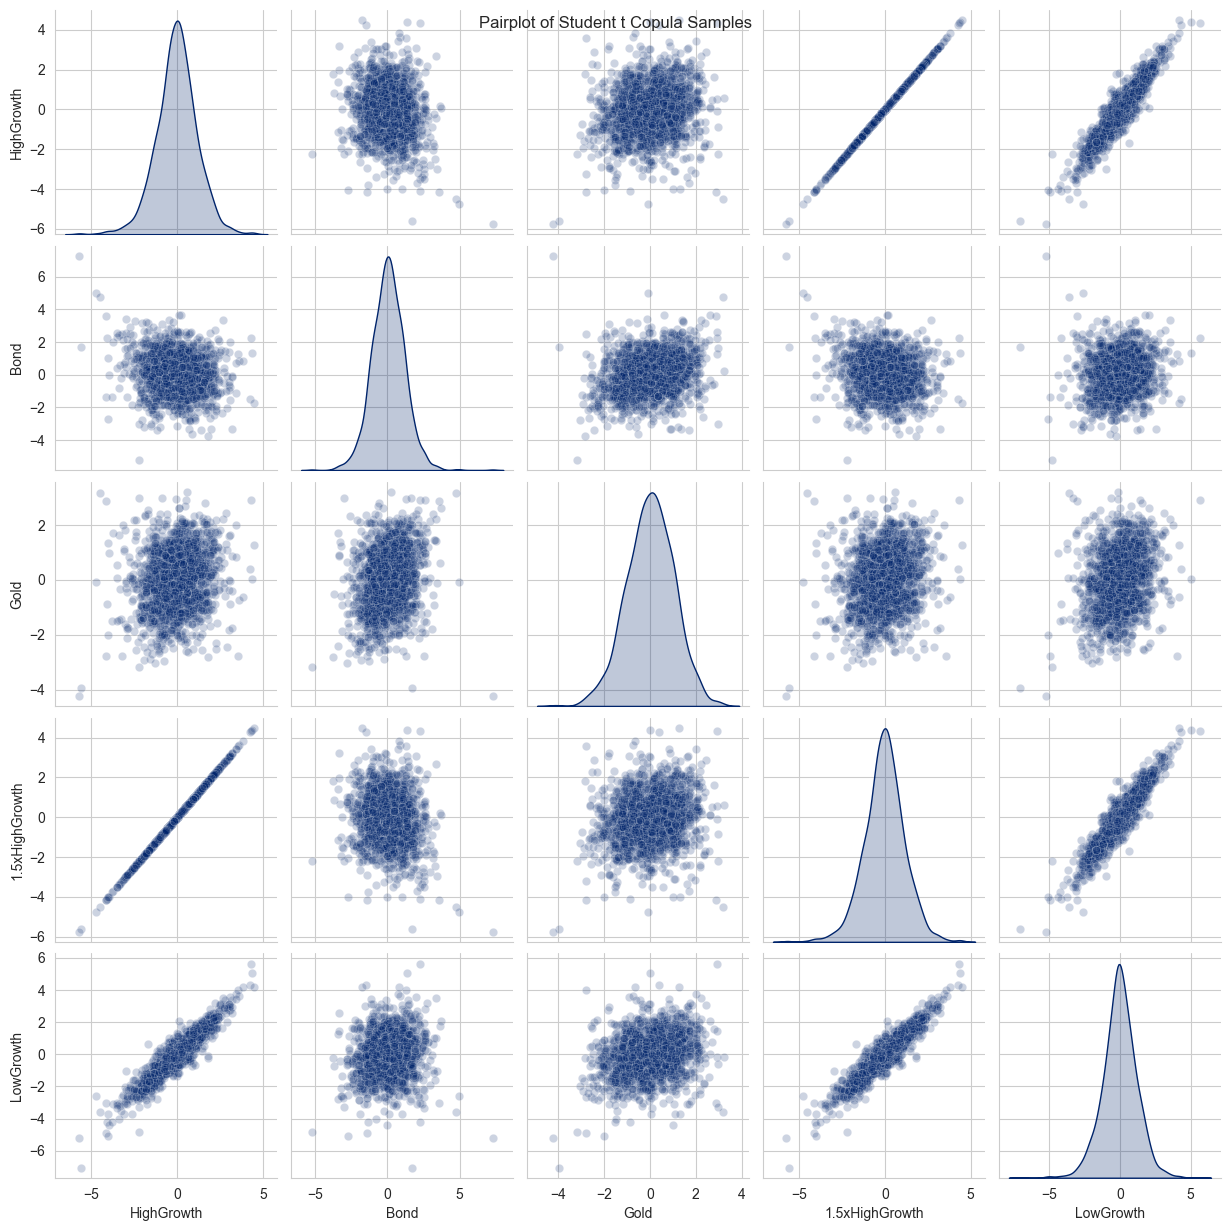

In [8]:
# dependence structure of the samples
plt.figure(figsize=(8, 8))
sns.pairplot(z_samples, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairplot of Student t Copula Samples')
plt.show()

<Figure size 800x800 with 0 Axes>

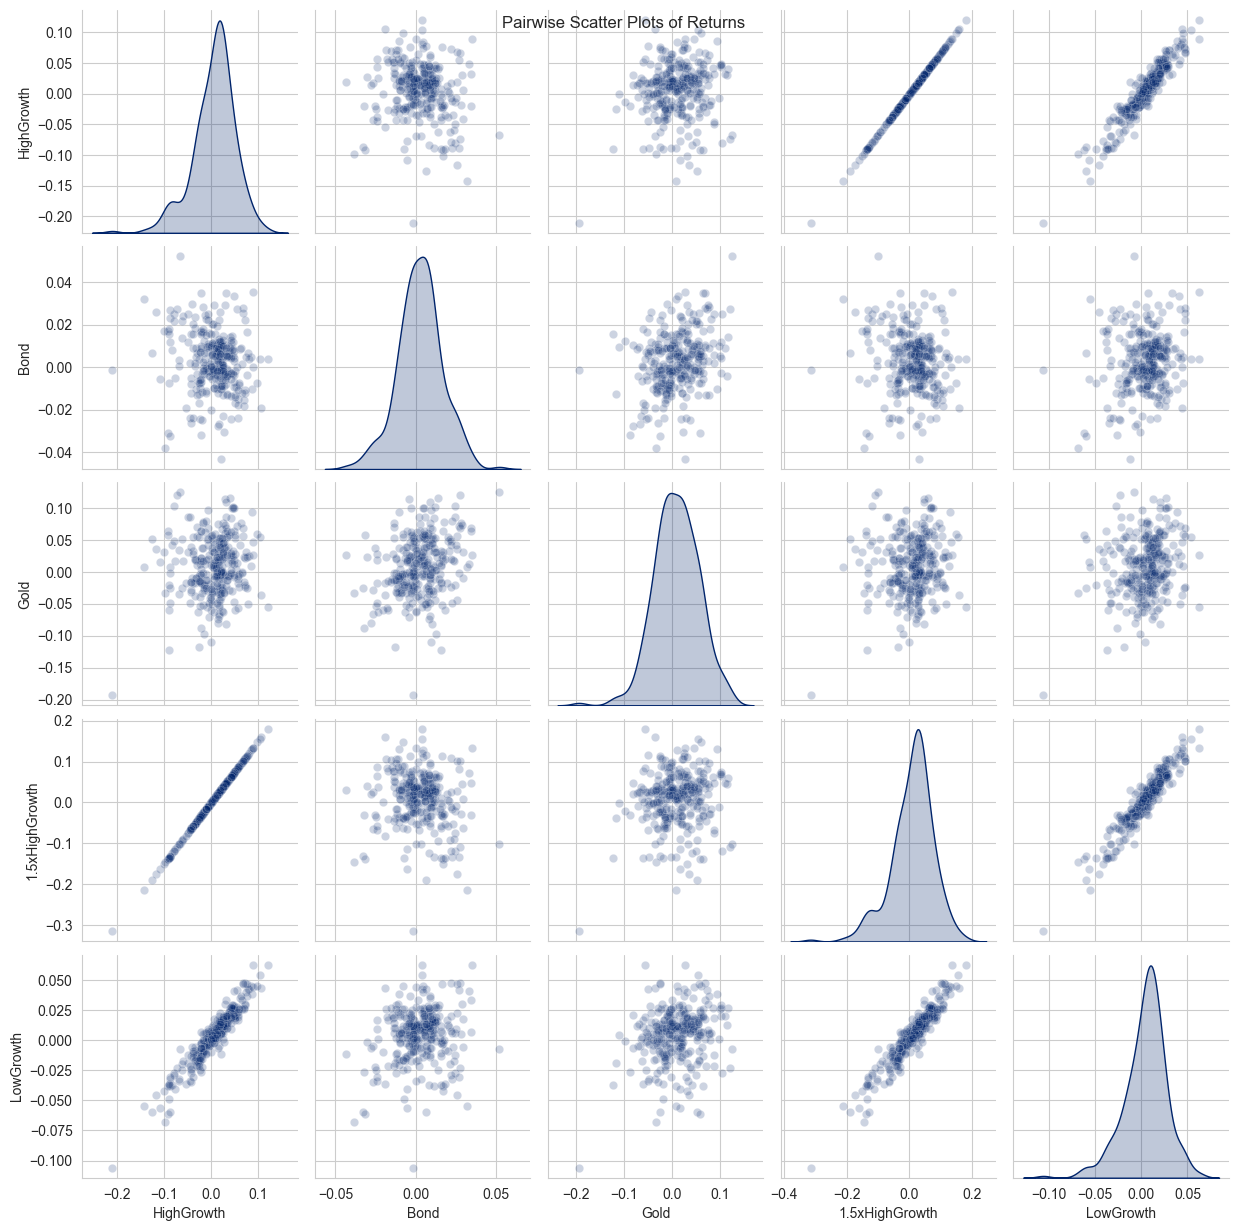

In [9]:
# for comparison, actual dependence structure
plt.figure(figsize=(8, 8))
sns.pairplot(returns, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairwise Scatter Plots of Returns')
plt.show()